# CNN Laboratorio — Notebook Base


Este notebook cubre los pasos de la rúbrica:
1) Preparar/organizar datos en Drive  
2) Split estratificado (train/val/test)   


## Librerías


In [1]:
import matplotlib.pyplot as plt
import random
import os, glob, shutil, json
import torch
import torchvision
import tifffile
import numpy as np

from PIL import Image
from torchvision import datasets, transforms
from datetime import datetime
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader

## 1) Montar Drive y definir rutas


In [2]:
PROJECT_DIR = './content'
RAW_DIR     = f'{PROJECT_DIR}/raw'      # imágenes sin etiqueta
LAB_DIR     = f'{PROJECT_DIR}/labeled'  # imágenes etiquetadas por CLASE/
DATA_DIR    = f'{PROJECT_DIR}/data'     # split final: train/val/test
RUNS_DIR    = f'{PROJECT_DIR}/runs'     # resultados, pesos y configs

for d in [PROJECT_DIR, RAW_DIR, LAB_DIR, DATA_DIR, RUNS_DIR]:
    os.makedirs(d, exist_ok=True)

print("Sube imágenes crudas a:", RAW_DIR)
print("Etiquetado manual: crea subcarpetas dentro de", LAB_DIR, "p.ej.:", LAB_DIR+"/clase_1, clase_2, ...")

Sube imágenes crudas a: ./content/raw
Etiquetado manual: crea subcarpetas dentro de ./content/labeled p.ej.: ./content/labeled/clase_1, clase_2, ...


## 2) Definir clases y verificar conteos en `labeled/`


In [3]:
# EDITA con las clases de su proyecto
CLASSES = ['airstrips', 'deforestation', 'forest', 'illegal_mining', 'illicit_crops_PCCA', 'water']  # ej: ['sano', 'enfermo']

counts = {}
for c in CLASSES:
    os.makedirs(os.path.join(LAB_DIR, c), exist_ok=True)
    counts[c] = len(glob.glob(os.path.join(LAB_DIR, c, '*')))
counts

{'airstrips': 5000,
 'deforestation': 5000,
 'forest': 5000,
 'illegal_mining': 5000,
 'illicit_crops_PCCA': 5000,
 'water': 5000}

## 3) Split estratificado → `data/train|val|test/CLASE/`


In [4]:
# Definición de porcentajes
train_r, val_r, test_r = 70, 20, 10
MAX_IMGS = 300

# Limpieza y creación de carpetas de destino
if os.path.exists(DATA_DIR):
    shutil.rmtree(DATA_DIR)

for split in ['train', 'val', 'test']:
    for c in CLASSES:
        os.makedirs(os.path.join(DATA_DIR, split, c), exist_ok=True)

# Función para convertir TIFF complejo a JPG estándar
def procesar_y_guardar_jpg(src_path, dest_folder):
    try:
        # Leer el TIFF con la librería especializada
        img_array = tifffile.imread(src_path)
        
        # Si la imagen tiene el formato (Canales, Alto, Ancho), la cambiamos a (Alto, Ancho, Canales)
        if img_array.ndim == 3 and img_array.shape[0] <= 4:
            img_array = np.transpose(img_array, (1, 2, 0))
            
        # Si tiene más de 3 canales (ej. bandas infrarrojas), nos quedamos solo con los 3 primeros (RGB)
        if img_array.ndim == 3 and img_array.shape[2] > 3:
            img_array = img_array[:, :, :3]
            
        # Si la imagen es 2D (escala de grises), la pasamos a 3 canales para que la CNN no falle
        if img_array.ndim == 2:
            img_array = np.stack((img_array,)*3, axis=-1)
            
        # Normalizar los valores a 8-bit (0-255) si vienen en 16-bit o flotante
        if img_array.dtype != np.uint8:
            img_array = img_array.astype(np.float32)
            # Evitamos divisiones por cero
            val_min, val_max = img_array.min(), img_array.max()
            if val_max > val_min:
                img_array = 255 * (img_array - val_min) / (val_max - val_min)
            img_array = img_array.astype(np.uint8)
            
        # Crear la imagen PIL y guardarla como JPG
        img_pil = Image.fromarray(img_array)
        
        # Generar el nuevo nombre de archivo (.jpg)
        base_name = os.path.basename(src_path)
        name_without_ext = os.path.splitext(base_name)[0]
        dest_path = os.path.join(dest_folder, f"{name_without_ext}.jpg")
        
        img_pil.save(dest_path, 'JPEG', quality=95)
        return True
    except Exception as e:
        print(f"Error procesando {src_path}: {e}")
        return False

# Proceso principal de split y conversión
for c in CLASSES:
    all_files = sorted(glob.glob(os.path.join(LAB_DIR, c, '*.tif'))) # Asumiendo que son .tif
    
    random.seed(42)
    random.shuffle(all_files)
    files = all_files[:MAX_IMGS]
    
    if len(files) < 20:
        print(f'⚠️ Clase {c} tiene muy pocas imágenes ({len(files)}).')
        if len(files) == 0: continue

    train_files, tmp = train_test_split(files, test_size=0.3, random_state=42, shuffle=True)
    rel = test_r / (val_r + test_r)
    val_files, test_files = train_test_split(tmp, test_size=rel, random_state=42, shuffle=True)

    print(f"Procesando clase {c}...")
    
    for src in train_files:
        procesar_y_guardar_jpg(src, os.path.join(DATA_DIR, 'train', c))
    for src in val_files:
        procesar_y_guardar_jpg(src, os.path.join(DATA_DIR, 'val', c))
    for src in test_files:
        procesar_y_guardar_jpg(src, os.path.join(DATA_DIR, 'test', c))

print(f"✅ Conversión y split completados en formato JPG: {DATA_DIR}")

Procesando clase airstrips...
Procesando clase deforestation...
Procesando clase forest...
Procesando clase illegal_mining...
Procesando clase illicit_crops_PCCA...
Procesando clase water...
✅ Conversión y split completados en formato JPG: ./content/data


In [5]:
def verificar_dataset(base_dir, classes):
    print(f"{'CLASE':<20} | {'TRAIN':<8} | {'VAL':<8} | {'TEST':<8} | {'TOTAL':<8}")
    print("-" * 60)
    
    total_general = 0
    
    for c in classes:
        # Contar archivos en cada carpeta de split
        n_train = len(os.listdir(os.path.join(base_dir, 'train', c)))
        n_val   = len(os.listdir(os.path.join(base_dir, 'val', c)))
        n_test  = len(os.listdir(os.path.join(base_dir, 'test', c)))
        
        row_total = n_train + n_val + n_test
        total_general += row_total
        
        print(f"{c:<20} | {n_train:<8} | {n_val:<8} | {n_test:<8} | {row_total:<8}")

    print("-" * 60)
    print(f"{'TOTAL GENERAL':<20} | {total_general:^32}")

# Ejecutar la verificación
verificar_dataset(DATA_DIR, CLASSES)

CLASE                | TRAIN    | VAL      | TEST     | TOTAL   
------------------------------------------------------------
airstrips            | 210      | 60       | 30       | 300     
deforestation        | 210      | 60       | 30       | 300     
forest               | 210      | 60       | 30       | 300     
illegal_mining       | 210      | 60       | 30       | 300     
illicit_crops_PCCA   | 210      | 60       | 30       | 300     
water                | 210      | 60       | 30       | 300     
------------------------------------------------------------
TOTAL GENERAL        |               1800              


## 4) DataLoaders (transformaciones mínimas)


In [6]:
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

IMG_SIZE = 224
BATCH_SIZE = 10

# Normalización estándar
mean = [0.485, 0.456, 0.406]
std  = [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])
eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

train_ds = datasets.ImageFolder(f"{DATA_DIR}/train", transform=train_tf)
val_ds   = datasets.ImageFolder(f"{DATA_DIR}/val",   transform=eval_tf)
test_ds  = datasets.ImageFolder(f"{DATA_DIR}/test",  transform=eval_tf)

class_names = train_ds.classes
num_classes = len(class_names)

train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_dl   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_dl  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print("Clases:", class_names, "| Dispositivo:", DEVICE)


Clases: ['airstrips', 'deforestation', 'forest', 'illegal_mining', 'illicit_crops_PCCA', 'water'] | Dispositivo: cuda


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8956583..2.5702832].


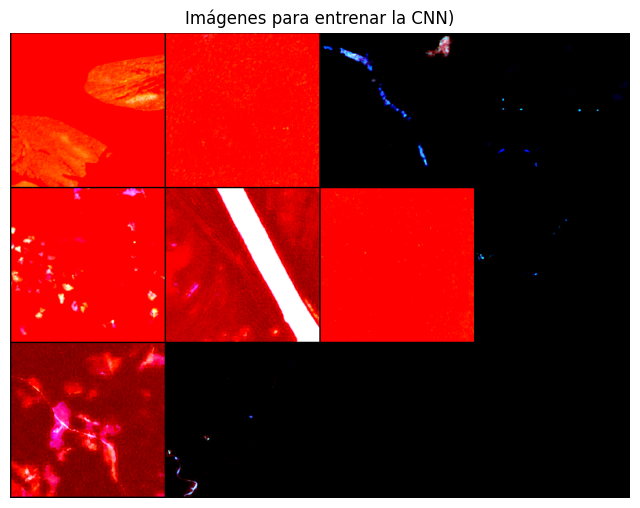

Etiquetas: ['water', 'forest', 'illegal_mining', 'airstrips', 'illicit_crops_PCCA', 'water', 'forest', 'airstrips', 'deforestation', 'illicit_crops_PCCA']


In [9]:
images, labels = next(iter(train_dl)) # Imágenes normalizadas
grid = torchvision.utils.make_grid(images[:12], nrow=4, padding=2)
npimg = grid.cpu().numpy().transpose(1, 2, 0)

plt.figure(figsize=(8, 8))
plt.imshow(npimg)
plt.title("Imágenes para entrenar la CNN)")
plt.axis("off")
plt.show()

print("Etiquetas:", [class_names[i] for i in labels[:12]])